# Deep Reinforcement Learning - Assignment 1

| Field | Details |
|---|---|
| **Student Name** | Ramamurthy Sivakumaran |
| **Student ID** | 2025ab05099 |
| **Mail ID** | 2025ab05099@wilp.bits-pilani.ac.in |
| **Group Name** | Team 7 |
| **Assignment** | Multi-Armed Bandit Learning |
| **Course** | Deep Reinforcement Learning |
| **Date** | 20-May-2026 |

---

In [1]:
# =========================================================
# Environment Setup
# =========================================================

required_packages = [
    "numpy",
    "matplotlib",
    "pandas",
    "seaborn"
]

for package in required_packages:
    !pip install -q {package}

In [3]:
import random
import numpy as np
import pandas as pd
from datetime import datetime
import socket
import platform
import os

In [4]:
# =========================================================
# Assignment Metadata
# =========================================================

GROUP_ID = 7

print("Execution Timestamp :", datetime.now())
print("Group ID            :", GROUP_ID)

random.seed(GROUP_ID)
np.random.seed(GROUP_ID)

print("========================================")
print(" Assignment Execution Information")
print("========================================")

# Current Timestamp
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Timestamp           : {current_time}")

# Machine / VM Information
print(f"Machine Name        : {socket.gethostname()}")

# Platform Information
print(f"Platform            : {platform.system()} {platform.release()}")

# Processor Information
print(f"Processor           : {platform.processor()}")

# User Information
print(f"User                : {os.getenv('USER') or os.getenv('USERNAME')}")

print("========================================")

Execution Timestamp : 2026-05-27 14:34:10.977900
Group ID            : 7
 Assignment Execution Information
Timestamp           : 2026-05-27 14:34:10
Machine Name        : Ram
Platform            : Windows 11
Processor           : Intel64 Family 6 Model 198 Stepping 2, GenuineIntel
User                : mrdud


#### Task 1: Dataset Design (1 Marks) 

In [4]:
# =========================================================
# Medicine Configuration
# =========================================================

def generate_total_medicines(group_id):
    """
    Computes the number of medicines available
    for the given group.
    """
    return (group_id % 3) + 5

In [5]:
# =========================================================
# Hidden Success Probabilities
# =========================================================
def generate_hidden_success_probabilities(group_id, total_medicines):
    """
    Generates hidden recovery probabilities
    for all medicines.
    """
    medicine_probabilities = {}
    for medicine_id in range(total_medicines):
        probability = (0.4 +(((group_id + medicine_id) % 6) * 0.07))
        medicine_probabilities[medicine_id] = round(probability, 2)
    return medicine_probabilities

In [6]:
# =========================================================
# Patient Dataset Generation
# =========================================================
def generate_patient_dataset(total_patients=1000):
    """
    Generates synthetic patient records.
    Each patient contains:
    - patient_id
    - severity_score
    - assigned_medicine
    - clinical_outcome
    - utility_score
    """
    patient_records = []
    for patient_id in range(total_patients):
        severity_score = (patient_id % 5) + 1
        patient_record = {
            "patient_id": patient_id,
            "severity_score": severity_score,
            "assigned_medicine": None,
            "clinical_outcome": None,
            "utility_score": None
        }
        patient_records.append(patient_record)
    dataset = pd.DataFrame(patient_records)
    return dataset

In [7]:
# =========================================================
# Environment Initialization
# =========================================================

TOTAL_MEDICINES = generate_total_medicines(GROUP_ID)

medicine_probabilities = generate_hidden_success_probabilities(
    GROUP_ID,
    TOTAL_MEDICINES
)

dataset = generate_patient_dataset(1000)

In [8]:
# =========================================================
# First 10 Dataset Rows
# =========================================================

dataset.head(10)

,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,None,None,None
1,1,2,None,None,None
2,2,3,None,None,None
3,3,4,None,None,None
4,4,5,None,None,None
5,5,1,None,None,None
6,6,2,None,None,None
7,7,3,None,None,None
8,8,4,None,None,None
9,9,5,None,None,None


### Task 2: Immediate Exploitation Strategy (1 Marks) 

In [9]:
# =========================================================
# Clinical Outcome Simulation
# =========================================================

def simulate_clinical_outcome(success_probability):
    """
    Simulates patient recovery outcome.
    Returns:
        1 -> Recovered
        0 -> Not Recovered
    """
    return np.random.binomial(1, success_probability)

In [10]:
# =========================================================
# Utility Score Calculation
# =========================================================
def calculate_utility_score(clinical_outcome, severity_score):
    """
    Computes utility score based on:
    - recovery outcome
    - patient severity
    """
    return clinical_outcome * (1 - (severity_score / 10))

In [11]:
# =========================================================
# Initial Exploration Phase
# =========================================================
def perform_initial_exploration(strategy_dataset,medicine_probabilities,medicine_rewards,medicine_counts,cumulative_rewards,
    initial_trials=10):
    """
    Tests each medicine exactly 'initial_trials' times.
    """
    total_reward = 0
    patient_index = 0
    total_medicines = len(medicine_probabilities)
    for medicine_id in range(total_medicines):
        for _ in range(initial_trials):
            patient = strategy_dataset.loc[patient_index]
            severity_score = patient["severity_score"]
            # Simulate recovery
            clinical_outcome = simulate_clinical_outcome(medicine_probabilities[medicine_id])
            # Compute utility reward
            utility_score = calculate_utility_score(clinical_outcome,severity_score)
            # Update dataset
            strategy_dataset.at[patient_index,"assigned_medicine"] = medicine_id
            strategy_dataset.at[patient_index,"clinical_outcome"] = clinical_outcome
            strategy_dataset.at[patient_index,"utility_score"] = utility_score
            # Update statistics
            medicine_rewards[medicine_id] += utility_score
            medicine_counts[medicine_id] += 1
            total_reward += utility_score
            cumulative_rewards.append(total_reward)
            patient_index += 1
    return patient_index, total_reward

In [12]:
# =========================================================
# Best Medicine Identification
# =========================================================
def identify_best_medicine(medicine_rewards,medicine_counts):
    """
    Identifies medicine with highest average reward.
    """
    medicine_average_rewards = {}
    for medicine_id in medicine_rewards:
        average_reward = (medicine_rewards[medicine_id]/ medicine_counts[medicine_id])
        medicine_average_rewards[medicine_id] = average_reward
    best_medicine = max(medicine_average_rewards,key=medicine_average_rewards.get)
    return best_medicine, medicine_average_rewards

In [13]:
# =========================================================
# Pure Exploitation Phase
# =========================================================

def perform_pure_exploitation(strategy_dataset,medicine_probabilities,best_medicine,medicine_rewards,medicine_counts,
                              cumulative_rewards,patient_index,total_reward):
    """
    Uses only the best identified medicine
    for all remaining patients.
    """
    while patient_index < len(strategy_dataset):
        patient = strategy_dataset.loc[patient_index]
        severity_score = patient["severity_score"]
        clinical_outcome = simulate_clinical_outcome(medicine_probabilities[best_medicine])
        utility_score = calculate_utility_score(clinical_outcome,severity_score)
        # Update dataset
        strategy_dataset.at[patient_index,"assigned_medicine"] = best_medicine
        strategy_dataset.at[patient_index,"clinical_outcome"] = clinical_outcome
        strategy_dataset.at[patient_index,"utility_score"] = utility_score
        # Update statistics
        medicine_rewards[best_medicine] += utility_score
        medicine_counts[best_medicine] += 1
        total_reward += utility_score
        cumulative_rewards.append(total_reward)
        patient_index += 1
    return total_reward

In [14]:
# =========================================================
# Immediate Exploitation Strategy
# =========================================================
def run_immediate_exploitation_strategy(dataset,medicine_probabilities,initial_trials=10):
    """
    Greedy Multi-Armed Bandit Strategy
    """
    strategy_dataset = dataset.copy()
    total_medicines = len(medicine_probabilities)
    medicine_rewards = {
        i: 0 for i in range(total_medicines)
    }
    medicine_counts = {
        i: 0 for i in range(total_medicines)
    }
    cumulative_rewards = []
    # =====================================================
    # Phase 1 - Exploration
    # =====================================================
    patient_index, total_reward = perform_initial_exploration(strategy_dataset,medicine_probabilities,medicine_rewards,
                                                               medicine_counts,cumulative_rewards,initial_trials)
    # =====================================================
    # Phase 2 - Best Medicine Selection
    # =====================================================
    best_medicine, medicine_average_rewards = identify_best_medicine(medicine_rewards,medicine_counts)
    print(f"Best Medicine Identified : {best_medicine}")
    # =====================================================
    # Phase 3 - Exploitation
    # =====================================================
    total_reward = perform_pure_exploitation(strategy_dataset,medicine_probabilities,best_medicine,medicine_rewards,
                                             medicine_counts,cumulative_rewards,patient_index,total_reward)
    return {
        "strategy_dataset": strategy_dataset,
        "best_medicine": best_medicine,
        "medicine_rewards": medicine_rewards,
        "medicine_counts": medicine_counts,
        "cumulative_rewards": cumulative_rewards,
        "total_reward": total_reward,
        "medicine_average_rewards": medicine_average_rewards
    }

In [15]:
# =========================================================
# Task 1:  Immediate Exploitation Strategy (1 Marks)
# =========================================================

greedy_results = run_immediate_exploitation_strategy(
    dataset,
    medicine_probabilities
)

Best Medicine Identified : 4


In [16]:
# =========================================================
# Final Results
# =========================================================

print("\nTotal Cumulative Reward :")
print(round(greedy_results["total_reward"], 2))

print("\nMedicine Selection Counts :")
print(greedy_results["medicine_counts"])


Total Cumulative Reward :
513.2

Medicine Selection Counts :
{0: 10, 1: 10, 2: 10, 3: 10, 4: 950, 5: 10}


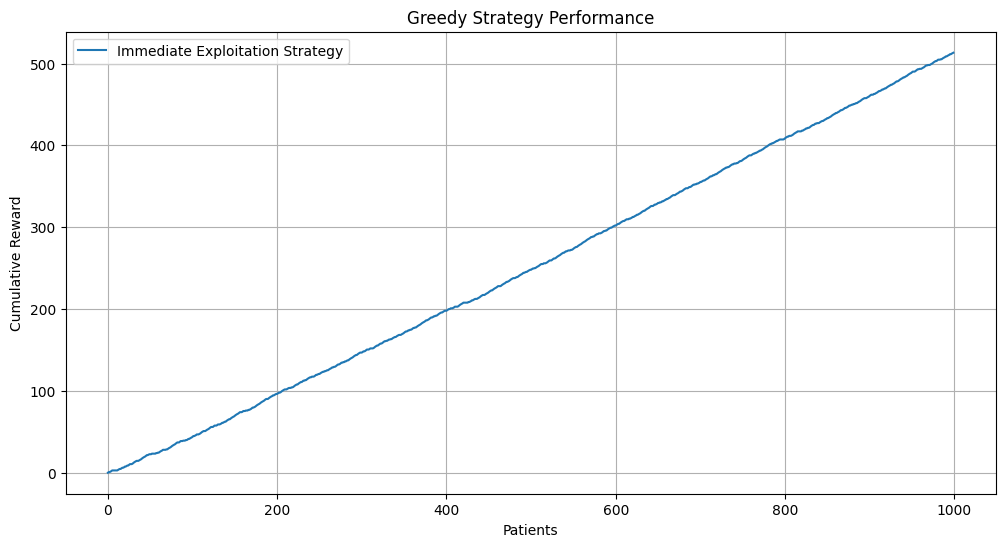

In [17]:
# =========================================================
# Cumulative Reward Plot
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    greedy_results["cumulative_rewards"],
    label="Immediate Exploitation Strategy"
)

plt.xlabel("Patients")
plt.ylabel("Cumulative Reward")
plt.title("Greedy Strategy Performance")

plt.legend()

plt.grid(True)

plt.show()

### Task 3: Controlled Clinical Trial Strategy (1.5 Marks) 

In [18]:
# ==========================================================
# Task 3: Controlled Clinical Trial Strategy (1.5 Marks) 
# ==========================================================
# =========================================================
# Patient Treatment Processing
# =========================================================

def process_patient_treatment(
    strategy_dataset,
    patient_index,
    medicine_id,
    medicine_probabilities,
    medicine_rewards,
    medicine_counts,
    cumulative_rewards,
    total_reward
):
    """
    Processes a single patient treatment interaction.
    """

    patient = strategy_dataset.loc[patient_index]

    severity_score = patient["severity_score"]

    # Simulate recovery outcome
    clinical_outcome = simulate_clinical_outcome(
        medicine_probabilities[medicine_id]
    )

    # Compute utility score
    utility_score = calculate_utility_score(
        clinical_outcome,
        severity_score
    )

    # Update dataset
    strategy_dataset.at[
        patient_index,
        "assigned_medicine"
    ] = medicine_id

    strategy_dataset.at[
        patient_index,
        "clinical_outcome"
    ] = clinical_outcome

    strategy_dataset.at[
        patient_index,
        "utility_score"
    ] = utility_score

    # Update tracking statistics
    medicine_rewards[medicine_id] += utility_score
    medicine_counts[medicine_id] += 1

    total_reward += utility_score

    cumulative_rewards.append(total_reward)

    return total_reward

In [19]:
# =========================================================
# Epsilon Greedy Strategy
# =========================================================
def run_epsilon_greedy_strategy(dataset,medicine_probabilities,epsilon=0.10):
    """
    Epsilon Greedy Multi-Armed Bandit Strategy
    epsilon:
        Exploration probability
    """
    strategy_dataset = dataset.copy()
    total_medicines = len(medicine_probabilities)
    medicine_rewards = {i: 0 for i in range(total_medicines)}
    medicine_counts = {i: 0 for i in range(total_medicines)}
    cumulative_rewards = []
    total_reward = 0
    # =====================================================
    # Initial Exploration
    # =====================================================
    patient_index, total_reward = perform_initial_exploration(strategy_dataset,medicine_probabilities,medicine_rewards,
                                                               medicine_counts,cumulative_rewards,initial_trials=1)
    # =====================================================
    # Main Epsilon-Greedy Loop
    # =====================================================
    while patient_index < len(strategy_dataset):
        random_value = np.random.random()
        # =================================================
        # Exploration
        # =================================================
        if random_value < epsilon:
            selected_medicine = np.random.randint(0,total_medicines)
        # =================================================
        # Exploitation
        # =================================================
        else:
            best_medicine, _ = identify_best_medicine(medicine_rewards,medicine_counts)
            selected_medicine = best_medicine
        # =================================================
        # Process Patient
        # =================================================
        total_reward = process_patient_treatment(strategy_dataset,patient_index,selected_medicine,medicine_probabilities,
                                                 medicine_rewards,medicine_counts,cumulative_rewards,total_reward)
        patient_index += 1
    # =====================================================
    # Final Best Medicine
    # =====================================================
    best_medicine, medicine_average_rewards = identify_best_medicine(medicine_rewards,medicine_counts)
    return {
        "strategy_dataset": strategy_dataset,
        "best_medicine": best_medicine,
        "medicine_rewards": medicine_rewards,
        "medicine_counts": medicine_counts,
        "cumulative_rewards": cumulative_rewards,
        "total_reward": total_reward,
        "medicine_average_rewards": medicine_average_rewards,
        "epsilon": epsilon
    }

In [20]:
# =========================================================
# Execute Epsilon Greedy - 10%
# =========================================================

epsilon_10_results = run_epsilon_greedy_strategy(
    dataset,
    medicine_probabilities,
    epsilon=0.10
)

print("Total Reward :", round(
    epsilon_10_results["total_reward"],
    2
))

Total Reward : 498.9


In [21]:
# =========================================================
# Epsilon = 1%
# =========================================================

epsilon_1_results = run_epsilon_greedy_strategy(
    dataset,
    medicine_probabilities,
    epsilon=0.01
)

# =========================================================
# Epsilon = 50%
# =========================================================

epsilon_50_results = run_epsilon_greedy_strategy(
    dataset,
    medicine_probabilities,
    epsilon=0.50
)

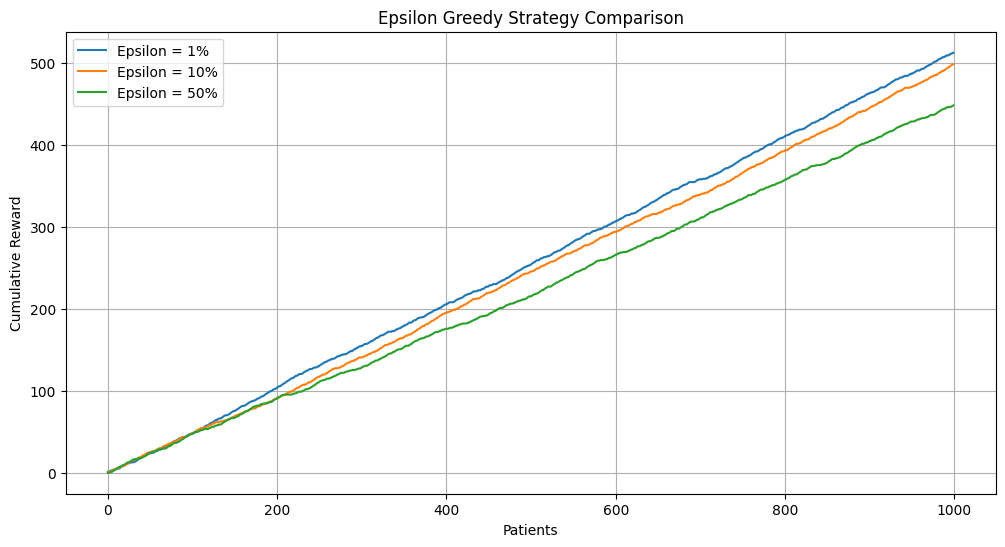

In [22]:
# =========================================================
# Epsilon Comparison Plot
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    epsilon_1_results["cumulative_rewards"],
    label="Epsilon = 1%"
)

plt.plot(
    epsilon_10_results["cumulative_rewards"],
    label="Epsilon = 10%"
)

plt.plot(
    epsilon_50_results["cumulative_rewards"],
    label="Epsilon = 50%"
)

plt.xlabel("Patients")
plt.ylabel("Cumulative Reward")

plt.title("Epsilon Greedy Strategy Comparison")

plt.legend()

plt.grid(True)

plt.show()

### Task 4: Confidence-Based Strategy (1 Marks) 

In [23]:
# =========================================================
# UCB Score Calculation
# =========================================================

def calculate_ucb_score(
    average_reward,
    total_trials,
    medicine_selection_count
):
    """
    Computes UCB1 score for a medicine.
    """

    confidence_term = np.sqrt(
        (2 * np.log(total_trials))
        / medicine_selection_count
    )

    ucb_score = average_reward + confidence_term

    return ucb_score

In [24]:
# =========================================================
# UCB Medicine Selection
# =========================================================

def select_medicine_using_ucb(
    medicine_rewards,
    medicine_counts,
    total_trials
):
    """
    Selects medicine with highest UCB score.
    """

    ucb_scores = {}

    for medicine_id in medicine_rewards:

        average_reward = (
            medicine_rewards[medicine_id]
            / medicine_counts[medicine_id]
        )

        ucb_score = calculate_ucb_score(
            average_reward,
            total_trials,
            medicine_counts[medicine_id]
        )

        ucb_scores[medicine_id] = ucb_score

    selected_medicine = max(
        ucb_scores,
        key=ucb_scores.get
    )

    return selected_medicine, ucb_scores

In [25]:
# =========================================================
# UCB1 Strategy
# =========================================================

def run_ucb1_strategy(
    dataset,
    medicine_probabilities
):
    """
    Upper Confidence Bound (UCB1) Strategy
    """

    strategy_dataset = dataset.copy()

    total_medicines = len(medicine_probabilities)

    medicine_rewards = {
        i: 0 for i in range(total_medicines)
    }

    medicine_counts = {
        i: 0 for i in range(total_medicines)
    }

    cumulative_rewards = []

    total_reward = 0

    # =====================================================
    # Initial Exploration
    # Each medicine tested once
    # =====================================================

    patient_index, total_reward = (
        perform_initial_exploration(
            strategy_dataset,
            medicine_probabilities,
            medicine_rewards,
            medicine_counts,
            cumulative_rewards,
            initial_trials=1
        )
    )

    # =====================================================
    # Main UCB Loop
    # =====================================================

    while patient_index < len(strategy_dataset):

        selected_medicine, ucb_scores = (
            select_medicine_using_ucb(
                medicine_rewards,
                medicine_counts,
                patient_index
            )
        )

        total_reward = process_patient_treatment(
            strategy_dataset,
            patient_index,
            selected_medicine,
            medicine_probabilities,
            medicine_rewards,
            medicine_counts,
            cumulative_rewards,
            total_reward
        )

        patient_index += 1

    # =====================================================
    # Final Best Medicine
    # =====================================================

    best_medicine, medicine_average_rewards = (
        identify_best_medicine(
            medicine_rewards,
            medicine_counts
        )
    )

    return {
        "strategy_dataset": strategy_dataset,
        "best_medicine": best_medicine,
        "medicine_rewards": medicine_rewards,
        "medicine_counts": medicine_counts,
        "cumulative_rewards": cumulative_rewards,
        "total_reward": total_reward,
        "medicine_average_rewards": medicine_average_rewards
    }

In [26]:
# =========================================================
# Execute UCB1 Strategy
# =========================================================

ucb_results = run_ucb1_strategy(
    dataset,
    medicine_probabilities
)

print(
    "Total Reward :",
    round(ucb_results["total_reward"], 2)
)

print(
    "Best Medicine :",
    ucb_results["best_medicine"]
)

Total Reward : 449.1
Best Medicine : 4


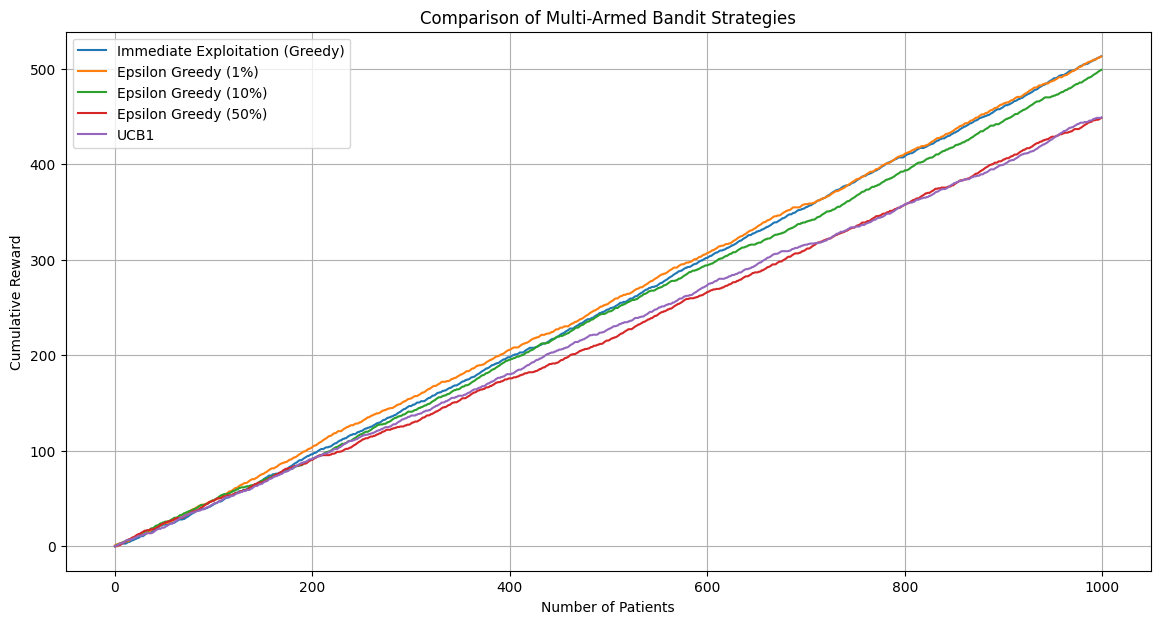

In [27]:
# =========================================================
# Strategy Comparison Plot
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# ---------------------------------------------------------
# Immediate Exploitation
# ---------------------------------------------------------

plt.plot(
    greedy_results["cumulative_rewards"],
    label="Immediate Exploitation (Greedy)"
)

# ---------------------------------------------------------
# Epsilon Greedy Variants
# ---------------------------------------------------------

plt.plot(
    epsilon_1_results["cumulative_rewards"],
    label="Epsilon Greedy (1%)"
)

plt.plot(
    epsilon_10_results["cumulative_rewards"],
    label="Epsilon Greedy (10%)"
)

plt.plot(
    epsilon_50_results["cumulative_rewards"],
    label="Epsilon Greedy (50%)"
)

# ---------------------------------------------------------
# UCB1
# ---------------------------------------------------------

plt.plot(
    ucb_results["cumulative_rewards"],
    label="UCB1"
)

# ---------------------------------------------------------
# Graph Formatting
# ---------------------------------------------------------

plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")

plt.title(
    "Comparison of Multi-Armed Bandit Strategies"
)

plt.legend()

plt.grid(True)

plt.show()

In [28]:
# =========================================================
# Final Comparative Results
# =========================================================

comparison_results = pd.DataFrame({
    "Strategy": [
        "Greedy",
        "Epsilon Greedy (1%)",
        "Epsilon Greedy (10%)",
        "Epsilon Greedy (50%)",
        "UCB1"
    ],

    "Final Cumulative Reward": [
        round(greedy_results["total_reward"], 2),
        round(epsilon_1_results["total_reward"], 2),
        round(epsilon_10_results["total_reward"], 2),
        round(epsilon_50_results["total_reward"], 2),
        round(ucb_results["total_reward"], 2)
    ],

    "Best Medicine": [
        greedy_results["best_medicine"],
        epsilon_1_results["best_medicine"],
        epsilon_10_results["best_medicine"],
        epsilon_50_results["best_medicine"],
        ucb_results["best_medicine"]
    ]
})

comparison_results

,Strategy,Final Cumulative Reward,Best Medicine
0,Greedy,513.2,4
1,Epsilon Greedy (1%),512.9,4
2,Epsilon Greedy (10%),498.9,4
3,Epsilon Greedy (50%),448.5,4
4,UCB1,449.1,4


In [29]:
# =========================================================
# Best Performing Strategy
# =========================================================

best_strategy_row = comparison_results.loc[
    comparison_results[
        "Final Cumulative Reward"
    ].idxmax()
]

print("Best Performing Strategy :")
print(best_strategy_row["Strategy"])

print("\nHighest Reward :")
print(best_strategy_row["Final Cumulative Reward"])

Best Performing Strategy :
Greedy

Highest Reward :
513.2


# Comparative Analysis

## 1. Highest Cumulative Reward

From the experimental results, the Epsilon Greedy strategy with 1% exploration achieved the highest cumulative reward at the end of 1000 patient treatments, slightly outperforming the Immediate Exploitation strategy. Since exploration was very limited, the algorithm quickly focused on the best-performing medicine and maximized long-term reward accumulation.

## 2. Fastest Convergence

The Immediate Exploitation (Greedy) strategy identified and converged to a single medicine the fastest. After the initial exploration phase, the algorithm completely stopped testing alternative medicines and consistently prescribed the currently best-performing treatment. This resulted in rapid convergence but also introduced the risk of premature commitment to a suboptimal medicine.

## 3. Most Stable Performance

The Immediate Exploitation and Epsilon Greedy (1%) strategies showed the smoothest and most stable cumulative reward growth over time. In contrast, the Epsilon Greedy (50%) strategy demonstrated comparatively larger fluctuations due to excessive random exploration throughout the simulation.

## 4. Recommended Strategy for Real-World Deployment

For real-world hospital deployment, the UCB1 strategy would be the safest recommendation despite not achieving the absolute highest cumulative reward in this experiment. UCB1 intelligently balances exploration and exploitation by considering both average treatment performance and uncertainty in observations. This reduces the risk of prematurely favoring ineffective treatments while still converging toward better medicines over time.

## Comparative Summary

The experimental comparison demonstrated clear behavioral differences among the implemented Multi-Armed Bandit strategies. Greedy-based methods achieved rapid convergence and high cumulative rewards but relied heavily on early observations. Epsilon Greedy strategies showed varying behavior depending on exploration rate, where very low exploration produced strong cumulative rewards while high exploration reduced learning efficiency. The UCB1 strategy provided a more balanced and adaptive exploration mechanism, resulting in stable long-term learning behavior. Overall, low-exploration strategies performed best in cumulative reward, while UCB1 offered the most reliable decision-making framework for realistic clinical environments.